# Proyek Analisis Sentimen

Opini dan ulasan yang saya gunakan diambil dari google playstore pada aplikasi Seabank

### Import Library

In [35]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score
 
import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
import emoji # Modul untuk menangani emoji dalam teks
import json # Modul untuk bekerja dengan data JSON
import joblib # Modul untuk menyimpan dan memuat model machine learning
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks


import csv # Modul untuk membaca dan menulis file CSV
import requests # Modul untuk melakukan permintaan HTTP
from io import StringIO # Untuk mengubah string menjadi objek file

from sklearn.feature_extraction.text import TfidfVectorizer  # Import TfidfVectorizer untuk mengubah teks menjadi representasi numerik
from sklearn.model_selection import train_test_split  # Import train_test_split untuk membagi dataset menjadi data pelatihan dan pengujian
from sklearn.naive_bayes import BernoulliNB # Naive Bayes untuk klasifikasi teks
from sklearn.ensemble import RandomForestClassifier # Random Forest untuk klasifikasi teks
from sklearn.linear_model import LogisticRegression # Regresi logistik untuk klasifikasi teks
from sklearn.tree import DecisionTreeClassifier # Pohon keputusan untuk klasifikasi teks
from sklearn.svm import SVC # Support Vector Classifier untuk klasifikasi teks
from sklearn.preprocessing import LabelEncoder 

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
import swifter # Mempercepat pemrosesan DataFrame dengan menggunakan multiprocessing 

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
 
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

from tqdm import tqdm # Import tqdm untuk menampilkan progress bar saat melakukan iterasi pada objek iterable.
tqdm.pandas()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\septi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\septi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Loading Dataset

In [21]:
# Load dataset dari CSV
app_reviews_df = pd.read_csv('ulasan_aplikasi.csv')

# Menampilkan dataset
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,96a94dec-e463-492b-97bf-ae7b107348bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak betul bank digital ini mantap, saat ini l...",5,695,3.15.0,2025-04-03 23:20:22,NaN,NaN,3.15.0
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0
2,08d5e0fe-dd5a-47f0-8c42-de0f30d36420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enakk betul aplikasi ini, sekarang ini lumayan...",5,678,3.15.0,2025-04-03 18:11:44,NaN,NaN,3.15.0
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0
4,67008cf9-3e1c-48de-83fd-ebb598a66612,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget sea bank mantap betul, saat ini lu...",5,501,3.16.2,2025-04-01 21:39:32,NaN,NaN,3.16.2


### Pembersihan Dataset

In [22]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              35000 non-null  object
 1   userName              35000 non-null  object
 2   userImage             35000 non-null  object
 3   content               35000 non-null  object
 4   score                 35000 non-null  int64 
 5   thumbsUpCount         35000 non-null  int64 
 6   reviewCreatedVersion  31694 non-null  object
 7   at                    35000 non-null  object
 8   replyContent          16091 non-null  object
 9   repliedAt             16091 non-null  object
 10  appVersion            31694 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.9+ MB


In [23]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Testing
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13618 entries, 1 to 34998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              13618 non-null  object
 1   userName              13618 non-null  object
 2   userImage             13618 non-null  object
 3   content               13618 non-null  object
 4   score                 13618 non-null  int64 
 5   thumbsUpCount         13618 non-null  int64 
 6   reviewCreatedVersion  13618 non-null  object
 7   at                    13618 non-null  object
 8   replyContent          13618 non-null  object
 9   repliedAt             13618 non-null  object
 10  appVersion            13618 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.8+ MB


### Preprocessing Text

#### Cleaning text

In [24]:
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

def cleaningText(text):
    text = remove_emoji(text)  # menghapus emoji
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

# Membersihkan teks
clean_df['text_clean'] = clean_df['content'].progress_apply(cleaningText)
clean_df.head()    

100%|██████████| 13618/13618 [00:18<00:00, 725.91it/s] 


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...


#### Casefolding

In [ ]:
def casefoldingText(text): 
    text = text.lower()
    return text

# Mengubah semua karakter dalam teks menjadi huruf kecil
clean_df['text_casefoldingText'] = clean_df['text_clean'].progress_apply(casefoldingText)
clean_df.head()    

100%|██████████| 13618/13618 [00:00<00:00, 167897.92it/s]


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...


#### Slang word

In [ ]:
# Mengambil kamus slangwords bahasa indonesia dari github
url = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt"
response = requests.get(url)
slangwords = json.loads(response.text)

with open("combined_slang_words.txt", "w", encoding="utf-8") as f:
    f.write(response.text)

def load_slangwords_dict(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.read()
        slang_dict = json.loads(data)
    return slang_dict

# Load ke variable
slangwords = load_slangwords_dict("combined_slang_words.txt")

def fix_slangwords(text):
    text = text.lower()
    words = text.split()
    fixed_words = [slangwords.get(word, word) for word in words]
    return ' '.join(fixed_words)

# Slang word normalization
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].progress_apply(fix_slangwords)
clean_df.head()

100%|██████████| 13618/13618 [00:00<00:00, 16358.94it/s]


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...


#### Tokenizing text

In [27]:
def tokenizingText(text): 
    text = word_tokenize(text)
    return text

# Memecah atau membagi string, teks menjadi daftar token
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].progress_apply(tokenizingText)
clean_df.head()    

100%|██████████| 13618/13618 [00:16<00:00, 834.38it/s] 


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[enak, oke, appsnya, mantap, benar, saat, ini,..."
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[enak, banget, appsnya, lancar, betul, saat, i..."
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[bagus, memberikan, kemudahan, bertransaksi, p..."
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[terbagus, enak, nyaman, memakainya, tanpa, ik..."
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[enak, banget, digunain, tanpa, ada, iklan, bu..."


#### Stemming 

In [28]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi stemming sederhana
def stemmed_wrapper(term):
    return stemmer.stem(term)

# Kumpulkan semua token unik dari kolom token
term_dict = {}

for document in clean_df['text_tokenizingText']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '  # Placeholder

print(f"Total unique terms: {len(term_dict)}")

# Stemming semua term unik + progress bar
for term in tqdm(term_dict, desc="Stemming words"):
    term_dict[term] = stemmed_wrapper(term)

# Fungsi untuk apply hasil stemming berdasarkan kamus
def get_stemmed_term(document):
    return [term_dict[term] for term in document]

# Pakai swifter untuk apply lebih cepat
clean_df['text_stemming'] = clean_df['text_tokenizingText'].swifter.apply(get_stemmed_term)
clean_df.head()

Total unique terms: 17435


Stemming words: 100%|██████████| 17435/17435 [4:17:49<00:00,  1.13it/s]   


Pandas Apply:   0%|          | 0/13618 [00:00<?, ?it/s]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stemming
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, benar, saat, ini,..."
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, betul, saat, i..."
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[bagus, memberikan, kemudahan, bertransaksi, p...","[bagus, beri, mudah, transaksi, bayar, dan, la..."
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[terbagus, enak, nyaman, memakainya, tanpa, ik...","[bagus, enak, nyaman, maka, tanpa, iklan, bug,..."
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, tanpa, ada, iklan, bu..."


#### Stopwords 

In [30]:
def filteringText(text): 
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

# Menghapus stopwords dalam teks
clean_df['text_stopword'] = clean_df['text_stemming'].progress_apply(filteringText)
clean_df.head() 

Pandas Apply:   0%|          | 0/13618 [00:00<?, ?it/s]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stemming,text_stopword
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, lumayan, enak, ik..."
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, lumayan, enak,..."
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[bagus, memberikan, kemudahan, bertransaksi, p...","[bagus, beri, mudah, transaksi, bayar, dan, la...","[bagus, mudah, transaksi, bayar, lainlainnya, ..."
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[terbagus, enak, nyaman, memakainya, tanpa, ik...","[bagus, enak, nyaman, maka, tanpa, iklan, bug,...","[bagus, enak, nyaman, iklan, bug, lambat, suka..."
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, iklan, bug, leletlele..."


#### Gabungkan token

In [31]:
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

# Gabungkan kembali token menjadi kalimat
clean_df['text_akhir'] = clean_df['text_stopword'].progress_apply(toSentence)
clean_df.head()

Pandas Apply:   0%|          | 0/13618 [00:00<?, ?it/s]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stemming,text_stopword,text_akhir
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, lumayan, enak, ik...",enak oke appsnya mantap lumayan enak iklan bug...
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, lumayan, enak,...",enak banget appsnya lancar lumayan enak iklan ...
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[bagus, memberikan, kemudahan, bertransaksi, p...","[bagus, beri, mudah, transaksi, bayar, dan, la...","[bagus, mudah, transaksi, bayar, lainlainnya, ...",bagus mudah transaksi bayar lainlainnya salah ...
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[terbagus, enak, nyaman, memakainya, tanpa, ik...","[bagus, enak, nyaman, maka, tanpa, iklan, bug,...","[bagus, enak, nyaman, iklan, bug, lambat, suka...",bagus enak nyaman iklan bug lambat suka transa...
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, iklan, bug, leletlele...",enak banget digunain iklan bug leletlelet sena...


### Pelabelan

In [32]:
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [33]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
 
def sentiment_analysis_lexicon_indonesia(tokens):
    #for word in tokens:
    
    score = 0
    # Inisialisasi skor sentimen ke 0
 
    for word in tokens:
        # Mengulangi setiap kata dalam teks
 
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in tokens:
        # Mengulangi setiap kata dalam teks (sekali lagi)
 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 
    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
        # Ini adalah bagian untuk menentukan polaritas netral 
 
    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [34]:
# Menggunakan fungsi sentiment_analysis_lexicon_indonesia untuk menghitung polaritas sentimen
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())
clean_df.head()

polarity
positive    6907
negative    5751
neutral      960
Name: count, dtype: int64


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stemming,text_stopword,text_akhir,polarity_score,polarity
1,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, benar, saat, ini,...","[enak, oke, appsnya, mantap, lumayan, enak, ik...",enak oke appsnya mantap lumayan enak iklan bug...,17,positive
3,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, betul, saat, i...","[enak, banget, appsnya, lancar, lumayan, enak,...",enak banget appsnya lancar lumayan enak iklan ...,12,positive
6,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[bagus, memberikan, kemudahan, bertransaksi, p...","[bagus, beri, mudah, transaksi, bayar, dan, la...","[bagus, mudah, transaksi, bayar, lainlainnya, ...",bagus mudah transaksi bayar lainlainnya salah ...,11,positive
7,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[terbagus, enak, nyaman, memakainya, tanpa, ik...","[bagus, enak, nyaman, maka, tanpa, iklan, bug,...","[bagus, enak, nyaman, iklan, bug, lambat, suka...",bagus enak nyaman iklan bug lambat suka transa...,15,positive
8,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, tanpa, ada, iklan, bu...","[enak, banget, digunain, iklan, bug, leletlele...",enak banget digunain iklan bug leletlelet sena...,11,positive


### Menyimpan hasil prepocessing data ke file csv

In [55]:
# Convert kolom list ke format JSON
for col in ['text_tokenizingText', 'text_stemming', 'text_stopword', 'text_akhir']:
    clean_df[col] = clean_df[col].apply(json.dumps)

# Simpan ke CSV
clean_df.to_csv("cleaned_data_fix.csv", index=False)

In [2]:
#  Membaca file csv
df_fix = pd.read_csv("cleaned_data_fix.csv")

for col in ['text_tokenizingText', 'text_stemming', 'text_stopword', 'text_akhir']:
    df_fix[col] = df_fix[col].fillna('[]').apply(json.loads)

In [3]:
# testing
df_fix.info()
df_fix.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13618 entries, 0 to 13617
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              13618 non-null  object
 1   userName              13618 non-null  object
 2   userImage             13618 non-null  object
 3   content               13618 non-null  object
 4   score                 13618 non-null  int64 
 5   thumbsUpCount         13618 non-null  int64 
 6   reviewCreatedVersion  13618 non-null  object
 7   at                    13618 non-null  object
 8   replyContent          13618 non-null  object
 9   repliedAt             13618 non-null  object
 10  appVersion            13618 non-null  object
 11  text_clean            13618 non-null  object
 12  text_casefoldingText  13618 non-null  object
 13  text_slangwords       13618 non-null  object
 14  text_tokenizingText   13618 non-null  object
 15  text_stemming         13618 non-null

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stemming,text_stopword,text_akhir,polarity_score,polarity
0,923be786-635d-444f-8288-696bcb0f61cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"enak oke appsnya mantap bener, saat ini lumaya...",5,636,3.15.0,2025-04-02 23:55:45,Hi Sobat SeaBank. Mohon maaf ya. Terkait kenda...,2025-04-05 07:55:26,3.15.0,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap bener saat ini lumayan...,enak oke appsnya mantap benar saat ini lumayan...,"[""enak"", ""oke"", ""appsnya"", ""mantap"", ""benar"", ...","[""enak"", ""oke"", ""appsnya"", ""mantap"", ""benar"", ...","[""enak"", ""oke"", ""appsnya"", ""mantap"", ""lumayan""...",enak oke appsnya mantap lumayan enak iklan bug...,17,positive
1,605d0b23-b9cf-4f14-8fc3-ebd4fa430821,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak banget appsnya lancar betul, saat ini lum...",5,509,3.15.0,2025-04-02 22:40:41,"Hi Sobat SeaBank, mohon maaf. Untuk kendalanya...",2025-04-02 20:16:08,3.15.0,Enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,enak banget appsnya lancar betul saat ini luma...,"[""enak"", ""banget"", ""appsnya"", ""lancar"", ""betul...","[""enak"", ""banget"", ""appsnya"", ""lancar"", ""betul...","[""enak"", ""banget"", ""appsnya"", ""lancar"", ""lumay...",enak banget appsnya lancar lumayan enak iklan ...,12,positive
2,b80673a3-af85-4483-aeb1-a997effb5a7e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus2 memberikan kemudahan bertransaksi pemba...,5,257,3.15.0,2025-03-24 23:25:24,"Hai Sobat SeaBank, terimakasih atas review dan...",2025-03-25 07:32:11,3.15.0,Bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,bagus memberikan kemudahan bertransaksi pembay...,"[""bagus"", ""memberikan"", ""kemudahan"", ""bertrans...","[""bagus"", ""beri"", ""mudah"", ""transaksi"", ""bayar...","[""bagus"", ""mudah"", ""transaksi"", ""bayar"", ""lain...",bagus mudah transaksi bayar lainlainnya salah ...,11,positive
3,d51b70d2-7192-44bf-97d6-07add5d4ef24,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Terbagus enak nyaman memakainya, tanpa iklan, ...",5,558,3.15.0,2025-03-28 23:52:42,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2025-03-28 16:12:45,3.15.0,Terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,terbagus enak nyaman memakainya tanpa iklan bu...,"[""terbagus"", ""enak"", ""nyaman"", ""memakainya"", ""...","[""bagus"", ""enak"", ""nyaman"", ""maka"", ""tanpa"", ""...","[""bagus"", ""enak"", ""nyaman"", ""iklan"", ""bug"", ""l...",bagus enak nyaman iklan bug lambat suka transa...,15,positive
4,9e2c711b-5aac-4da5-aba9-33ea9bb34638,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Enak2 👍banget digunain tanpa ada iklan, bug at...",5,476,3.16.2,2025-03-31 23:27:31,Hi Sobat SeaBank. Terima kasih atas reviewnya ...,2025-04-01 04:04:13,3.16.2,Enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,enak banget digunain tanpa ada iklan bug ataup...,"[""enak"", ""banget"", ""digunain"", ""tanpa"", ""ada"",...","[""enak"", ""banget"", ""digunain"", ""tanpa"", ""ada"",...","[""enak"", ""banget"", ""digunain"", ""iklan"", ""bug"",...",enak banget digunain iklan bug leletlelet sena...,11,positive


### Visualisasi Polarity

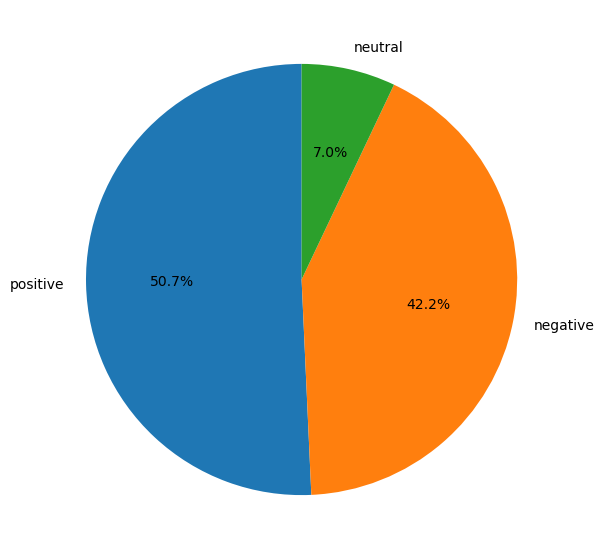

In [60]:
# Menghitung distribusi kata negatif, positif dan neutral dalam pie chart 
plt.figure(figsize=(7, 7))
plt.pie(df_fix['polarity'].value_counts(), labels=['positive', 'negative', 'neutral'], autopct='%1.1f%%', startangle=90)
plt.show()

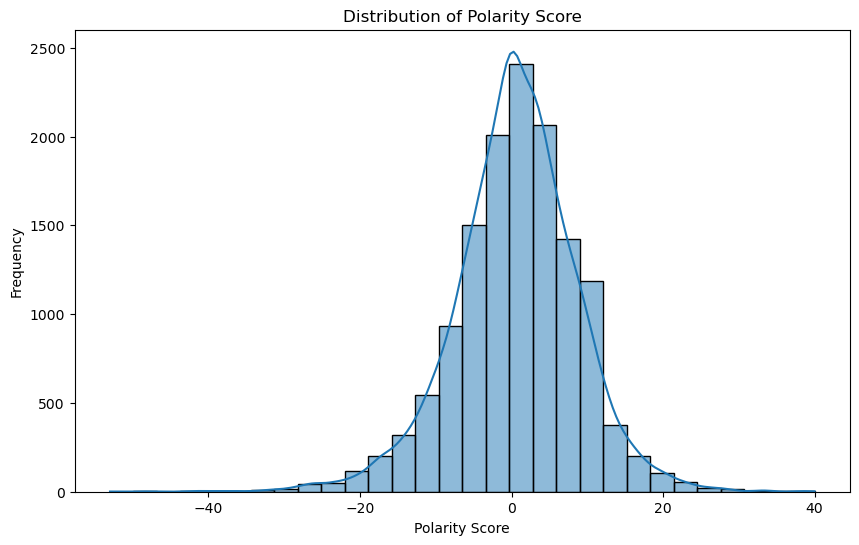

In [61]:
# Menghitung polarity score dengan histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_fix['polarity_score'], bins=30, kde=True)
plt.title('Distribution of Polarity Score')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

### Eksplorasi Label

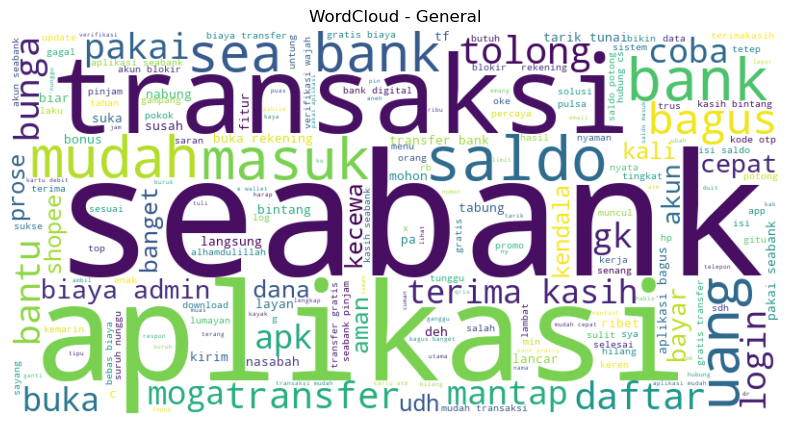

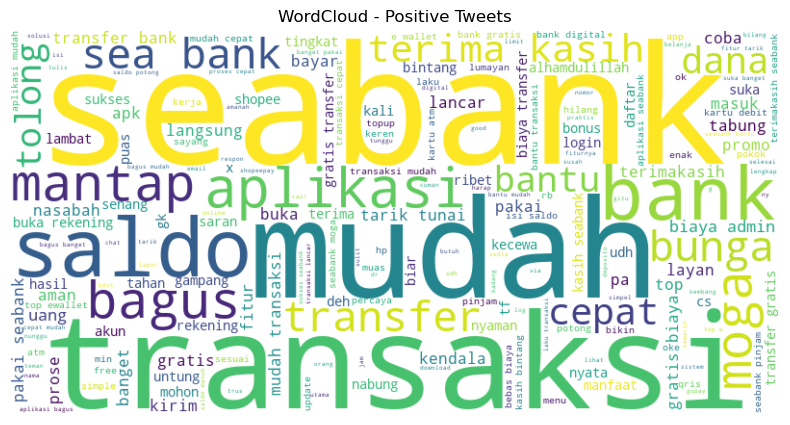

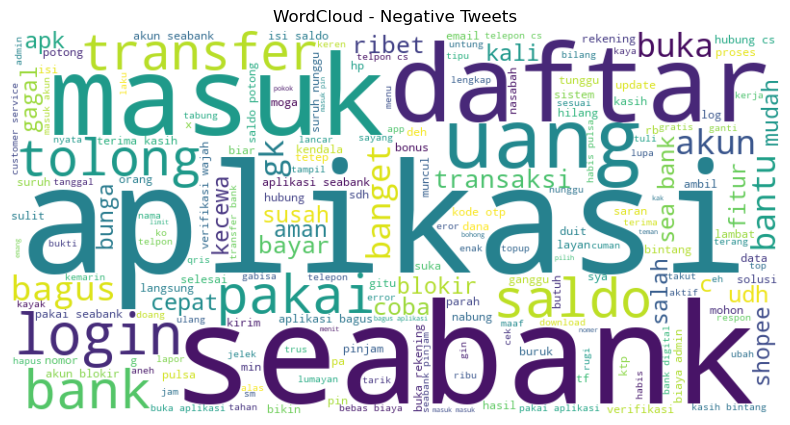

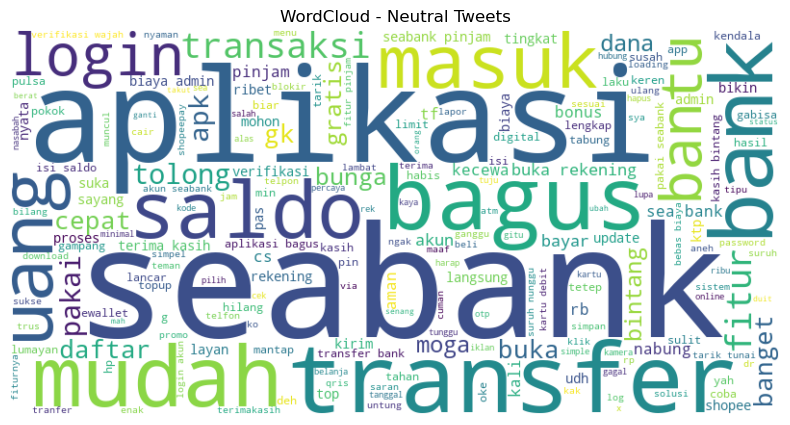

In [62]:
# Daftar polaritas yang ingin ditampilkan WordCloud-nya
polarities = ['general', 'positive', 'negative', 'neutral']

# Loop untuk menghasilkan WordCloud berdasarkan polaritas
for polarity in polarities:
    if polarity == 'general':
        words = ' '.join(df_fix['text_akhir'])
        title = 'WordCloud - General'
    else:
        words = ' '.join(df_fix[df_fix['polarity'] == polarity]['text_akhir'])
        title = f'WordCloud - {polarity.capitalize()} Tweets'

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)

    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

### Data Splitting dan Ekstraksi Fitur dengan TF-IDF

In [36]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = df_fix['text_akhir']
y = df_fix['polarity']
 
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

# Label encoding (ubah label jadi angka)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
 
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
 
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42)

### Modeling

#### **Naive Bayes**

In [14]:
# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()
 
# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)
 
# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())
 
# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)
 
# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7758399118780981
Naive Bayes - accuracy_test: 0.7345814977973568


#### **Random Forest**

In [66]:
# Membuat objek model Random Forest
random_forest = RandomForestClassifier()
 
# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)
 
# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())
 
# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)
 
# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9997246190563613
Random Forest - accuracy_test: 0.8215859030837004


#### **Decision Tree**

In [67]:
# Membuat objek model Decision Tree
decision_tree = DecisionTreeClassifier()
 
# Melatih model Decision Tree pada data pelatihan
decision_tree.fit(X_train.toarray(), y_train)
 
# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())
 
# Evaluasi akurasi model Decision Tree
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)
 
# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9997246190563613
Decision Tree - accuracy_test: 0.7433920704845814


#### **Support Vector Machine(SVM)**

In [68]:
# Membuat objek model Support Vector Machine(SVM)
support_vector_machine = SVC()
 
# Melatih model Support Vector Machine(SVM) pada data pelatihan
support_vector_machine.fit(X_train.toarray(), y_train)
 
# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = support_vector_machine.predict(X_train.toarray())
y_pred_test_dt = support_vector_machine.predict(X_test.toarray())
 
# Evaluasi akurasi model Support Vector Machine(SVM)
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)
 
# Menampilkan akurasi
print('Support Vector Machine(SVM) - accuracy_train:', accuracy_train_dt)
print('Support Vector Machine(SVM) - accuracy_test:', accuracy_test_dt)

Support Vector Machine(SVM) - accuracy_train: 0.9545621442996145
Support Vector Machine(SVM) - accuracy_test: 0.8722466960352423


#### **Logistic Regression**

In [37]:
# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9171103359647512
Logistic Regression - accuracy_test: 0.8744493392070485


*Menyimpan model Logistic Regression yang memiliki akurasi terbesar*

In [39]:
# Simpan model Logistic Regression ke file
joblib.dump(logistic_regression, 'logistic_regression.pkl')

# Simpan vectorizer TF-IDF ke file
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model dan vectorizer berhasil disimpan.")

Model dan vectorizer berhasil disimpan.


### Deep Learning

*Import library*

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf  
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam

*Tokenisasi text dengan oov_token dan padding*

In [5]:
tokenizer = Tokenizer(num_words=3000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

# Ubah teks menjadi urutan angka
X_sequences = tokenizer.texts_to_sequences(X)

# Padding agar semua input punya panjang yang sama
X_padded = pad_sequences(X_sequences, padding='post', truncating="post", maxlen=10)

print("Tokenizer: ",tokenizer.word_index)
print("Sequences: ",X_sequences)
print("Padded: ",X_padded)

Tokenizer:  {'<OOV>': 1, 'seabank': 2, 'aplikasi': 3, 'bank': 4, 'mudah': 5, 'saldo': 6, 'transfer': 7, 'transaksi': 8, 'masuk': 9, 'bagus': 10, 'pakai': 11, 'gratis': 12, 'uang': 13, 'banget': 14, 'biaya': 15, 'bantu': 16, 'cs': 17, 'buka': 18, 'cepat': 19, 'akun': 20, 'moga': 21, 'tolong': 22, 'kasih': 23, 'bunga': 24, 'fitur': 25, 'daftar': 26, 'rekening': 27, 'login': 28, 'bayar': 29, 'admin': 30, 'terima': 31, 'top': 32, 'sea': 33, 'apk': 34, 'dana': 35, 'aman': 36, 'suruh': 37, 'layan': 38, 'gk': 39, 'proses': 40, 'bintang': 41, 'mantap': 42, 'pinjam': 43, 'coba': 44, 'tarik': 45, 'kirim': 46, 'kali': 47, 'verifikasi': 48, 'shopee': 49, 'ribet': 50, 'pulsa': 51, 'tf': 52, 'kecewa': 53, 'isi': 54, 'pas': 55, 'tabung': 56, 'kartu': 57, 'blokir': 58, 'lancar': 59, 'suka': 60, 'mohon': 61, 'tunai': 62, 'nunggu': 63, 'langsung': 64, 'biar': 65, 'hubung': 66, 'bonus': 67, 'tingkat': 68, 'susah': 69, 'data': 70, 'deh': 71, 'udh': 72, 'atm': 73, 'nabung': 74, 'potong': 75, 'kendala': 76,

*Encode label sentimen (y)*

In [9]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Konversi label ke one-hot encoding 
y_onehot = to_categorical(y_encoded)

*Split data latih & uji (pakai X_padded dan y_onehot)*

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_onehot, test_size=0.3, random_state=42, stratify=y_onehot)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(9532, 10) (9532, 3)
(4086, 10) (4086, 3)


*Early stopping*

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',     # Pantau loss validasi
    patience=3,             # Tunggu 3 epoch sebelum stop
    restore_best_weights=True # Kembalikan bobot terbaik
)

checkpoint = ModelCheckpoint(
    'best_model.h5', # Nama file untuk menyimpan model terbaik
    monitor='val_accuracy', # Pantau akurasi validasi
    save_best_only=True, # Hanya simpan model terbaik
    mode='max', # Simpan model dengan akurasi tertinggi
    verbose=1 # Tampilkan pesan saat menyimpan model
)

#### **LSTM**

*Membangun model*

In [36]:
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=5000, output_dim=128, input_length=X_padded.shape[1])) 

# Layer LSTM
model.add(LSTM(128, return_sequences=True, dropout=0.2, kernel_regularizer=l2(0.01)))
model.add(LSTM(64, kernel_regularizer=l2(0.01)))

# Fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer (3 kelas: positif, negatif, netral)
model.add(Dense(3, activation='softmax'))

*Optimizer*

In [37]:
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

*Melatih model*

In [38]:
hist = model.fit(
    X_train,             # Input data
    y_train,             # Target label
    epochs=50,               # Jumlah epoch 
    batch_size=64,           # Ukuran batch 
    validation_split=0.2,     # 20% data training akan digunakan untuk validasi
    callbacks=[early_stop, checkpoint],   # Early stop untuk menghentikan training jika tidak ada perbaikan
    verbose=1                 # Menampilkan progress training
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4978 - loss: 3.5720
Epoch 1: val_accuracy did not improve from 0.83377
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 182ms/step - accuracy: 0.4983 - loss: 3.5644 - val_accuracy: 0.7431 - val_loss: 1.2824
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7641 - loss: 1.0408
Epoch 2: val_accuracy did not improve from 0.83377
120/120 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.7642 - loss: 1.0393 - val_accuracy: 0.7855 - val_loss: 0.6605
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8315 - loss: 0.5668
Epoch 3: val_accuracy did not improve from 0.83377
120/120 ━━━━━━━━━━━━━━━━━━━━ 52s 264ms/step - accuracy: 0.8315 - loss: 0.5666 - val_accuracy: 0.8060 - val_loss: 0.5738
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8531 - loss: 0.4558
Epoch 4: val_accuracy did not improve from 0.83377
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.8531 - loss: 0.4558 - val_

*Evaluasi model*

In [35]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi Model: {accuracy*100:.2f}%")

128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8265 - loss: 0.4949
Akurasi Model: 82.97%


#### **GRU**

*Membangun model*

In [43]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=5000, output_dim=128, input_length=X_padded.shape[1]))

# GRU Layer
model.add(Bidirectional(GRU(128, return_sequences=True, dropout=0.2)))  
model.add(Bidirectional(GRU(64, return_sequences=False, kernel_regularizer=l2(0.001))))  

# Fully Connected Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(3, activation='softmax'))

*Optimizer*

In [44]:
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

*Melatih model*

In [ ]:
hist = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5653 - loss: 1.2199
Epoch 1: val_accuracy improved from -inf to 0.79211, saving model to best_model.h5


137/137 ━━━━━━━━━━━━━━━━━━━━ 99s 326ms/step - accuracy: 0.5660 - loss: 1.2182 - val_accuracy: 0.7921 - val_loss: 0.6406
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8361 - loss: 0.5318
Epoch 2: val_accuracy improved from 0.79211 to 0.81735, saving model to best_model.h5


137/137 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.8361 - loss: 0.5317 - val_accuracy: 0.8173 - val_loss: 0.5197
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8600 - loss: 0.4054
Epoch 3: val_accuracy improved from 0.81735 to 0.83662, saving model to best_model.h5


137/137 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.8600 - loss: 0.4054 - val_accuracy: 0.8366 - val_loss: 0.4631
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8857 - loss: 0.3341
Epoch 4: val_accuracy improved from 0.83662 to 0.83846, saving model to best_model.h5


137/137 ━━━━━━━━━━━━━━━━━━━━ 45s 230ms/step - accuracy: 0.8856 - loss: 0.3341 - val_accuracy: 0.8385 - val_loss: 0.4845
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.8983 - loss: 0.3020
Epoch 5: val_accuracy did not improve from 0.83846
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 303ms/step - accuracy: 0.8983 - loss: 0.3020 - val_accuracy: 0.8339 - val_loss: 0.4777
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9011 - loss: 0.2724
Epoch 6: val_accuracy did not improve from 0.83846
137/137 ━━━━━━━━━━━━━━━━━━━━ 98s 418ms/step - accuracy: 0.9011 - loss: 0.2725 - val_accuracy: 0.8380 - val_loss: 0.5040
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9147 - loss: 0.2431
Epoch 7: val_accuracy did not improve from 0.83846
137/137 ━━━━━━━━━━━━━━━━━━━━ 81s 410ms/step - accuracy: 0.9147 - loss: 0.2432 - val_accuracy: 0.8251 - val_loss: 0.5215
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9088 - loss: 0.2518
Epoch 8: va

*Evaluasi model*

In [48]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi Model: {accuracy*100:.2f}%")

86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8447 - loss: 0.4572
Akurasi Model: 84.29%
